
### 📝 Contexto General del Negocio
En el sector de telecomunicaciones, retener a un cliente activo es hasta 7 veces más económico que adquirir uno nuevo. Este proyecto busca analizar el comportamiento histórico de los usuarios para identificar qué factores (tarifas altas, tipo de contrato, problemas técnicos) influyen en que una persona decida abandonar la compañía o portarse a la competencia.

### 🎯 Objetivos de esta Fase:
1. **Comprender los Datos:** Inspeccionar la estructura del dataset oficial (`WA_Fn-UseC_-Telco-Customer-Churn.csv`).
2. **Limpieza Inicial:** Detectar inconsistencias, valores nulos o formatos de datos incorrectos.
3. **Métricas Clave:** Calcular la tasa actual de deserción (Churn) y descubrir los primeros patrones visuales de riesgo.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
# 1. Cargar del dataset 
path = "../data/sample/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(path)


In [3]:
print("============ 1. DIMENSIONES DEL DATASET ============")
print(f"Total de Filas (Clientes): {df.shape[0]}")
print(f"Total de Columnas (Variables): {df.shape[1]}")



============ 1. DIMENSIONES DEL DATASET ============
Total de Filas (Clientes): 7043
Total de Columnas (Variables): 21


In [5]:
print("\n============ 2. PRIMERAS FILAS DEL DATASET ============")
print(df.head().T)


============ 2. PRIMERAS FILAS DEL DATASET ============
                                 0             1               2  \
customerID              7590-VHVEG    5575-GNVDE      3668-QPYBK   
gender                      Female          Male            Male   
SeniorCitizen                    0             0               0   
Partner                        Yes            No              No   
Dependents                      No            No              No   
tenure                           1            34               2   
PhoneService                    No           Yes             Yes   
MultipleLines     No phone service            No              No   
InternetService                DSL           DSL             DSL   
OnlineSecurity                  No           Yes             Yes   
OnlineBackup                   Yes            No             Yes   
DeviceProtection                No           Yes              No   
TechSupport                     No            No           

In [26]:
print("\n============ 3. TIPOS DE DATOS ============")
print(df.dtypes)


============ 3. TIPOS DE DATOS ============
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [4]:
print("\n============ 4. RESUMEN ESTADÍSTICO ============")
print(df.describe(include='all').T)


============ 4. RESUMEN ESTADÍSTICO ============
                   count unique               top  freq       mean        std  \
customerID          7043   7043        7590-VHVEG     1        NaN        NaN   
gender              7043      2              Male  3555        NaN        NaN   
SeniorCitizen     7043.0    NaN               NaN   NaN   0.162147   0.368612   
Partner             7043      2                No  3641        NaN        NaN   
Dependents          7043      2                No  4933        NaN        NaN   
tenure            7043.0    NaN               NaN   NaN  32.371149  24.559481   
PhoneService        7043      2               Yes  6361        NaN        NaN   
MultipleLines       7043      3                No  3390        NaN        NaN   
InternetService     7043      3       Fiber optic  3096        NaN        NaN   
OnlineSecurity      7043      3                No  3498        NaN        NaN   
OnlineBackup        7043      3                No  3088    

In [5]:
print("\n============ 5. VALORES FALTANTES ============")
print(df.isnull().sum())


============ 5. VALORES FALTANTES ============
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


| Nombre | Traducción al Español |
| :--- | :--- |
| `customerID` | ID del Cliente |
| `gender` | Género |
| `SeniorCitizen` | Adulto Mayor (Jubilado) |
| `Partner` | Tiene Pareja |
| `Dependents` | Tiene Dependientes |
| `PhoneService` | Servicio Telefónico |
| `MultipleLines` | Líneas Múltiples |
| `InternetService` | Servicio de Internet |
| `OnlineSecurity` | Seguridad en Línea |
| `OnlineBackup` | Respaldo en la Nube |
| `DeviceProtection` | Protección de Equipo |
| `TechSupport` | Soporte Técnico Premium |
| `StreamingTV` | Televisión por Streaming |
| `StreamingMovies` | Películas por Streaming |
| `Contract` | Tipo de Contrato |
| `PaperlessBilling` | Facturación Electrónica |
| `PaymentMethod` | Método de Pago |
| `tenure` | Antigüedad (Meses) |
| `MonthlyCharges` | Cargo Mensual |
| `TotalCharges` | Cargo Total Acumulado |
| `Churn` | Deserción (Fuga de Clientes) |

### 🛠️ Corrección Crítica de Datos: El caso 'TotalCharges'

**Diagnóstico del Problema:** En el resumen estadístico se evidenció que la columna `TotalCharges` aparece como tipo `object` (texto) y sus métricas matemáticas (`mean`, `min`, `max`) se muestran como `NaN`. Al inspeccionar a fondo, descubrimos que existen **11 registros con espacios en blanco (" ")** que corresponden a clientes completamente nuevos con 0 meses de antigüedad (`tenure == 0`). Al contener texto, Python bloquea cualquier cálculo matemático, lo que haría fallar nuestros futuros modelos en PySpark.

**Estrategia de Solución:**
1. **Conversión Forzada (`errors='coerce'`):** Forzamos la columna a tipo numérico flotante. Los 11 espacios vacíos se transforman automáticamente en valores nulos oficiales (`NaN`).
2. **Imputación por Lógica de Negocio (`.fillna(0.0)`):** Como son clientes nuevos que acaban de ingresar hoy a la empresa, su gasto acumulado histórico real es **0.0**. Reemplazamos los nulos con cero para preservar los registros sin alterar la información.

In [6]:
# Paso 1: Forzar la conversión a número flotante. Los espacios vacíos pasan a ser NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Paso 2: Imputar los NaN con 0.0 (Lógica de negocio para clientes con tenure = 0)
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

print("============ 6. VERIFICACIÓN POST-LIMPIEZA ============")
print(f"Nuevo tipo de dato asignado a TotalCharges: {df['TotalCharges'].dtype}")
print("\nNuevas estadísticas reales calculadas para TotalCharges (¡Ya no hay NaN!):")
print(df['TotalCharges'].describe().round(2))

============ 6. VERIFICACIÓN POST-LIMPIEZA ============
Nuevo tipo de dato asignado a TotalCharges: float64

Nuevas estadísticas reales calculadas para TotalCharges (¡Ya no hay NaN!):
count    7043.00
mean     2279.73
std      2266.79
min         0.00
25%       398.55
50%      1394.55
75%      3786.60
max      8684.80
Name: TotalCharges, dtype: float64


## 📊 2. Análisis Gráfico de Negocio

A continuación, responderemos visualmente las preguntas planteadas en la investigación sobre el comportamiento de deserción (*Churn*) de los clientes.

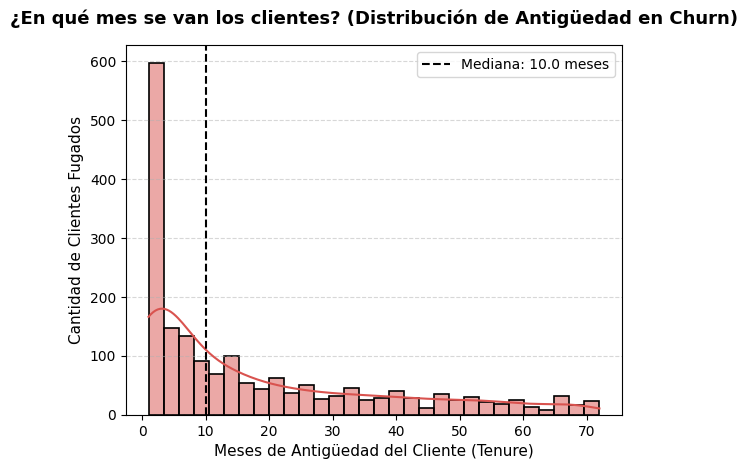

In [7]:
# Filtrar solo a los clientes que abandonaron la empresa
churners = df[df['Churn'] == 'Yes']

# Graficar histograma con línea de densidad (KDE)
sns.histplot(data=churners, x='tenure', kde=True, color='#d9534f', bins=30, linewidth=1.2)

# Personalización ejecutiva del gráfico
plt.title("¿En qué mes se van los clientes? (Distribución de Antigüedad en Churn)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Meses de Antigüedad del Cliente (Tenure)", fontsize=11)
plt.ylabel("Cantidad de Clientes Fugados", fontsize=11)
plt.axvline(churners['tenure'].median(), color='black', linestyle='--', label=f"Mediana: {churners['tenure'].median()} meses")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


💡 Conclusión de Negocio: El 50% de los clientes que abandonan se van antes de los 10.0 meses.
Existe un pico crítico de deserción en el Mes 1. Es urgente crear alertas de retención tempranas.

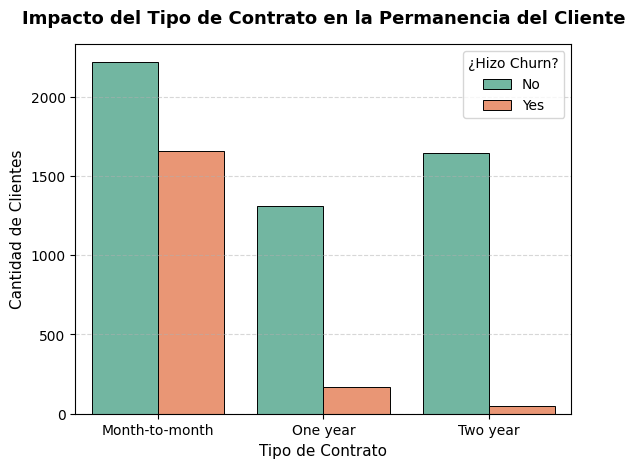

In [8]:
# Graficar el impacto del contrato utilizando un gráfico de barras agrupadas
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2', edgecolor='black', linewidth=0.7)

plt.title("Impacto del Tipo de Contrato en la Permanencia del Cliente", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Tipo de Contrato", fontsize=11)
plt.ylabel("Cantidad de Clientes", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="¿Hizo Churn?")

plt.show()



💡 Conclusión de Negocio: Los clientes con contrato 'Month-to-month' (Mes a Mes) representan la gran mayoría
de las fugas. Los contratos a 1 y 2 años actúan como un escudo blindado contra la deserción.

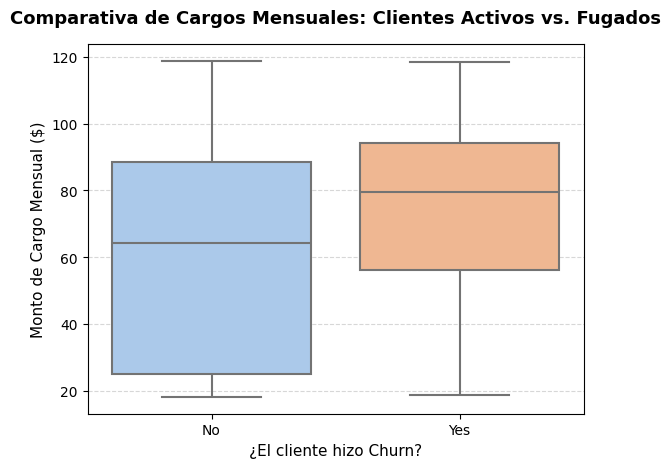

In [9]:
import warnings
warnings.simplefilter("ignore")
# Graficar diagramas de caja (Boxplot) para comparar los precios mensuales gastados
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='pastel', linewidth=1.5)

plt.title("Comparativa de Cargos Mensuales: Clientes Activos vs. Fugados", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("¿El cliente hizo Churn?", fontsize=11)
plt.ylabel("Monto de Cargo Mensual ($)", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


💡 Conclusión de Negocio: La mediana de los cargos mensuales de los clientes que se van es notablemente
más alta ($80) en comparación con los clientes que se quedan ($65). El precio elevado es un gatillador de fuga.

### 🌐 3. Análisis de Servicios y su Relación con la Deserción

Para diseñar estrategias de retención efectivas, no basta con saber cuánto pagan los clientes o qué contrato tienen; es vital descubrir qué servicios (Internet, Seguridad en Línea, Soporte Técnico, etc.) están asociados a las tasas más altas de abandono. Esto nos permitirá identificar si existe algún producto defectuoso o con problemas de fidelización.

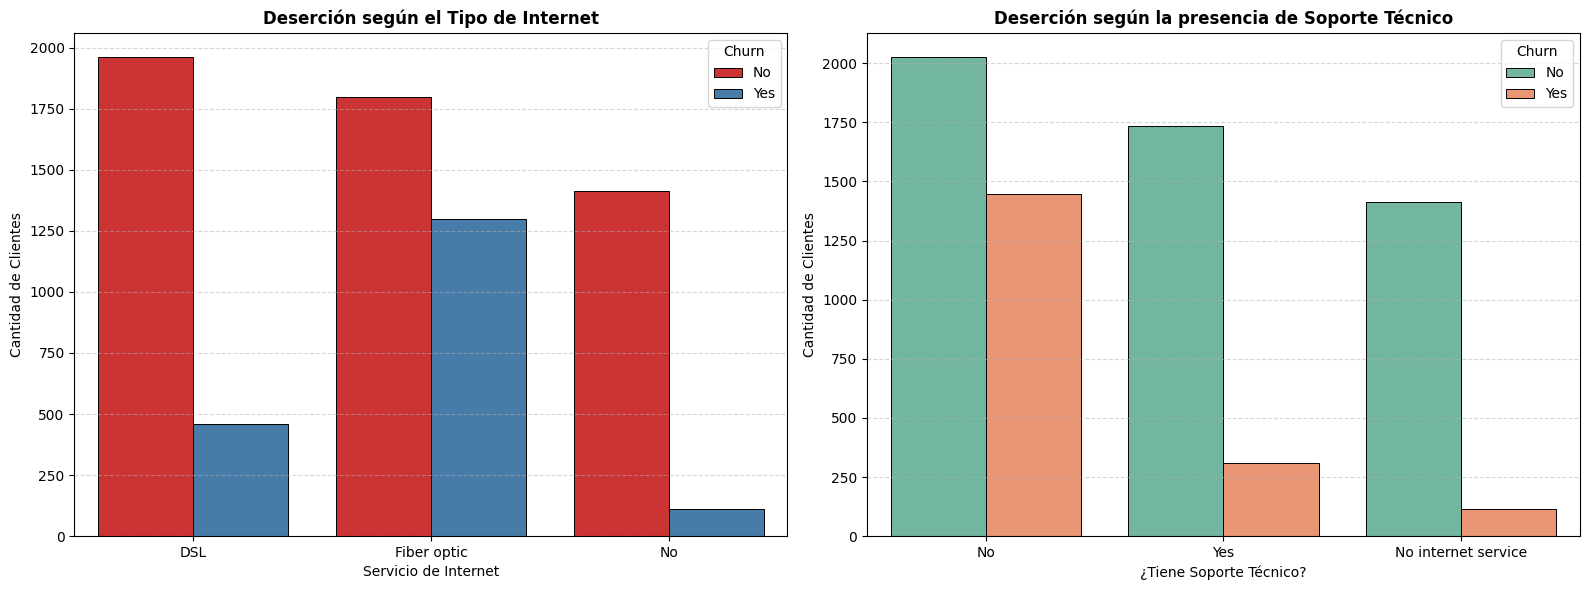

In [10]:
# Crear una figura con dos gráficos en paralelo (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico A: Tipo de Servicio de Internet vs Churn
sns.countplot(data=df, x='InternetService', hue='Churn', palette='Set1', ax=axes[0], edgecolor='black', linewidth=0.7)
axes[0].set_title('Deserción según el Tipo de Internet', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Servicio de Internet')
axes[0].set_ylabel('Cantidad de Clientes')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Gráfico B: Soporte Técnico vs Churn
sns.countplot(data=df, x='TechSupport', hue='Churn', palette='Set2', ax=axes[1], edgecolor='black', linewidth=0.7)
axes[1].set_title('Deserción según la presencia de Soporte Técnico', fontsize=12, fontweight='bold')
axes[1].set_xlabel('¿Tiene Soporte Técnico?')
axes[1].set_ylabel('Cantidad de Clientes')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


============ CONCLUSIONES DE SERVICIOS ============
1. ALERTA EN FIBRA ÓPTICA: Los clientes con Fibra Óptica ('Fiber optic') se van significativamente
   más que los de DSL, a pesar de ser un servicio más caro. Esto sugiere problemas de precio o de calidad.
2. EL SOPORTE TÉCNICO RETIENE: Los clientes que NO tienen Soporte Técnico ('No') presentan la mayor tasa
    de fuga. Brindar soporte es clave para mitigar el Churn.

## 🏁 Conclusiones  del Análisis Exploratorio (EDA)

1. **Calidad de la Data:** Se resolvió  el problema de formato en `TotalCharges` imputando 11 valores vacíos con `0.0`, correspondientes a usuarios nuevos
2. **Perfil del Cliente Fugado:** El usuario con mayor probabilidad de abandonar Telco es aquel con contrato **Mes a Mes**, que utiliza **Fibra Óptica**, **no tiene contratado Soporte Técnico** y paga tarifas mensuales elevadas (cercanas o superiores a los $80).
